# DATA PREPROCESSING

### Dataset: Sephora Products and Skincare Reviews

The dataset contains information about all beauty products (over 8,000) from the Sephora online store, including product and brand names, prices, ingredients, ratings, and all features.

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors





In [70]:
import kagglehub

path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

print("Path to dataset files:", path)

Path to dataset files: /home/alberto/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2


In [71]:
# List all files in the downloaded dataset directory
files = os.listdir(path)
print("Downloaded files:", files)

Downloaded files: ['reviews_750-1250.csv', 'reviews_500-750.csv', 'reviews_0-250.csv', 'reviews_1250-end.csv', 'product_info.csv', 'reviews_250-500.csv']


In [72]:
csv_file = os.path.join(path, "product_info.csv")
df = pd.read_csv(csv_file)

# Check the first few rows of the dataframe
print(df.head())

  product_id               product_name  brand_id brand_name  loves_count  \
0    P473671    Fragrance Discovery Set      6342      19-69         6320   
1    P473668    La Habana Eau de Parfum      6342      19-69         3827   
2    P473662  Rainbow Bar Eau de Parfum      6342      19-69         3253   
3    P473660       Kasbah Eau de Parfum      6342      19-69         3018   
4    P473658  Purple Haze Eau de Parfum      6342      19-69         2691   

   rating  reviews            size                      variation_type  \
0  3.6364     11.0             NaN                                 NaN   
1  4.1538     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
2  4.2500     16.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
3  4.4762     21.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
4  3.2308     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   

  variation_value  ... online_only out_of_stock  sephora_exclusive  \
0             NaN  ...

In [73]:
print("Shape of the DataFrame:", df.shape)
print(df.info())



Shape of the DataFrame: (8494, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     

We have 8494 records and 27 features, since we will not use all of them we can identify columns like brand_id and variation_desc, which are redundant or irrelevant for content-based filtering and drop them.

Import reviews and merge with product info

In [74]:
base_path = path

df_reviews_1 = pd.read_csv(os.path.join(base_path, "reviews_0-250.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_2 = pd.read_csv(os.path.join(base_path, "reviews_250-500.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_3 = pd.read_csv(os.path.join(base_path, "reviews_500-750.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_4 = pd.read_csv(os.path.join(base_path, "reviews_750-1250.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_5 = pd.read_csv(os.path.join(base_path, "reviews_1250-end.csv"),
                           index_col=0, dtype={'author_id': 'str'})



In [75]:
df_reviews = pd.concat([df_reviews_1,df_reviews_2,df_reviews_3,df_reviews_4,df_reviews_5],axis=0)
print("df_reviews shape: ",df_reviews.shape)

df_reviews shape:  (1094411, 18)


In [76]:
# Lets check df_product_info which columns that similar with df_reviews
cols_to_use = df.columns.difference(df_reviews.columns)
cols_to_use = list(cols_to_use)
cols_to_use.append('product_id')
print(cols_to_use)

['brand_id', 'child_count', 'child_max_price', 'child_min_price', 'highlights', 'ingredients', 'limited_edition', 'loves_count', 'new', 'online_only', 'out_of_stock', 'primary_category', 'reviews', 'sale_price_usd', 'secondary_category', 'sephora_exclusive', 'size', 'tertiary_category', 'value_price_usd', 'variation_desc', 'variation_type', 'variation_value', 'product_id']


In [77]:
df = pd.merge(df_reviews, df[cols_to_use], how='outer', on=['product_id', 'product_id'])
df.shape

(1100554, 40)

In [78]:
# df_merged.head(20)

In [79]:
missing = []
unique = []
types = []
variables = []
count = []

for item in df.columns:
    variables.append(item)
    missing.append(df[item].isnull().sum())
    unique.append(df[item].nunique())
    types.append(df[item].dtypes)
    count.append(len(df[item]))
    
output = pd.DataFrame({
    'variable': variables, 
    'dtype': types,
    'count': count,
    'unique': unique,
    'missing': missing, 
   
})
print("Df info : ")
output.sort_values("missing",ascending=False).reset_index(drop=True)

Df info : 


,variable,dtype,count,unique,missing
0,variation_desc,object,1100554,935,1091034
1,sale_price_usd,float64,1100554,88,1090576
2,value_price_usd,float64,1100554,174,1069365
3,child_max_price,float64,1100554,222,644796
4,child_min_price,float64,1100554,208,644796
5,helpfulness,float64,1100554,3767,567735
6,review_title,object,1100554,364105,316797
7,hair_color,object,1100554,7,232911
8,eye_color,object,1100554,6,215771
9,skin_tone,object,1100554,14,176682


Discard columns that are not useful

In [80]:
df_old = df.copy()
columns_to_drop = [
    'variation_desc',             # Detailed variation description (not needed)
    'sale_price_usd',             # Sale price information
    'value_price_usd',            # Discounted price info
    'child_max_price',            # Variation-specific max price
    'child_min_price',            # Variation-specific min price
    'helpfulness',                # Review helpfulness score
    'review_title',               # Title of the review (optional)
    'tertiary_category',          # Extra categorization (if primary/secondary are sufficient)
    'highlights',                 # List of product highlights (not used in our current model)
    'variation_value',            # Specific variation detail
    'variation_type',             # Type of variation (redundant if not used)
    'size',                       # Product size (if not needed)
    'total_feedback_count',       # Feedback counts (can be considered noise)
    'total_neg_feedback_count',   # Negative feedback details
    'total_pos_feedback_count',   # Positive feedback details
    'submission_time',            # Timestamp of submission
    'limited_edition',            # Limited edition flag
    'sephora_exclusive',          # Exclusivity flag
    'child_count',                # Count of product variations
    'brand_id',                   # Numeric brand ID (redundant with brand_name)
    'online_only',
    'new'                 # Online-only flag (if not needed)
]

# Drop the unwanted columns from df
df_clean = df.drop(columns=columns_to_drop, axis=1)

# Verify the resulting DataFrame structure
print(df_clean.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100554 entries, 0 to 1100553
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   author_id           1094411 non-null  object 
 1   rating              1094411 non-null  float64
 2   is_recommended      926423 non-null   float64
 3   review_text         1092967 non-null  object 
 4   skin_tone           923872 non-null   object 
 5   eye_color           884783 non-null   object 
 6   skin_type           982854 non-null   object 
 7   hair_color          867643 non-null   object 
 8   product_id          1100554 non-null  object 
 9   product_name        1094411 non-null  object 
 10  brand_name          1094411 non-null  object 
 11  price_usd           1094411 non-null  float64
 12  ingredients         1077711 non-null  object 
 13  loves_count         1100554 non-null  int64  
 14  out_of_stock        1100554 non-null  int64  
 15  primary_categor

## EDA

Basic data overview

In [81]:
# Summary statistics for numerical columns
print(df_clean.describe())

# Summary for all columns (including object types)
print(df_clean.describe(include='all'))


             rating  is_recommended     price_usd   loves_count  out_of_stock  \
count  1.094411e+06   926423.000000  1.094411e+06  1.100554e+06  1.100554e+06   
mean   4.299158e+00        0.839962  4.900838e+01  1.064307e+05  3.182942e-02   
std    1.149444e+00        0.366642  4.004338e+01  1.674201e+05  1.755458e-01   
min    1.000000e+00        0.000000  3.000000e+00  0.000000e+00  0.000000e+00   
25%    4.000000e+00        1.000000  2.500000e+01  1.630000e+04  0.000000e+00   
50%    5.000000e+00        1.000000  3.900000e+01  4.814300e+04  0.000000e+00   
75%    5.000000e+00        1.000000  6.200000e+01  1.234390e+05  0.000000e+00   
max    5.000000e+00        1.000000  1.900000e+03  1.401068e+06  1.000000e+00   

            reviews  
count  1.100276e+06  
mean   2.151789e+03  
std    2.524573e+03  
min    1.000000e+00  
25%    5.390000e+02  
50%    1.337000e+03  
75%    2.891000e+03  
max    2.128100e+04  
         author_id        rating  is_recommended  \
count      1094411  

#### Handle missing data

In [82]:
# Count missing values per column
missing_values = df_clean.isnull().sum()
print("Missing Values per Column:\n", missing_values)

# Optionally, view the percentage of missing values for each column
missing_percentage = (df_clean.isnull().mean() * 100).round(2)
print("Percentage of Missing Values:\n", missing_percentage)


Missing Values per Column:
 author_id               6143
rating                  6143
is_recommended        174131
review_text             7587
skin_tone             176682
eye_color             215771
skin_type             117700
hair_color            232911
product_id                 0
product_name            6143
brand_name              6143
price_usd               6143
ingredients            22843
loves_count                0
out_of_stock               0
primary_category           0
reviews                  278
secondary_category         8
dtype: int64
Percentage of Missing Values:
 author_id              0.56
rating                 0.56
is_recommended        15.82
review_text            0.69
skin_tone             16.05
eye_color             19.61
skin_type             10.69
hair_color            21.16
product_id             0.00
product_name           0.56
brand_name             0.56
price_usd              0.56
ingredients            2.08
loves_count            0.00
out_of_stock  

After analyzing the missing values, we found that critical text fields used for vectorization—specifically, the 'ingredients' (2.08% missing) and 'review_text' (0.69% missing) columns—needed to be complete for accurate text processing. Therefore, we dropped rows where these fields were missing. For other essential fields such as 'author_id', 'rating', 'product_name', 'brand_name', and 'price_usd', which had very low missing percentages (<1%), we also removed any incomplete rows to ensure data integrity. In contrast, the user attribute columns—'skin_tone' (16.05%), 'eye_color' (19.61%), 'skin_type' (10.69%), and 'hair_color' (21.16%)—had moderate missing rates; instead of dropping these, we imputed their missing values with a placeholder value ("Unknown") to preserve the overall dataset size.

In [83]:

# Step 1: Drop rows with missing critical text fields and essential identifiers.
critical_columns = ['ingredients', 'review_text', 'author_id', 'rating', 'product_name', 'brand_name', 'price_usd','secondary_category']
df = df_clean.dropna(subset=critical_columns, how='any')

# Step 2: Impute missing values for user attribute columns with "Unknown".
user_attribute_columns = ['skin_tone', 'eye_color', 'skin_type', 'hair_color']
for col in user_attribute_columns:
    df[col] = df[col].fillna("Unknown")

# Optional: Verify the updated missing values summary.
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

print("Updated Missing Values per Column:\n", missing_values)
print("\nPercentage of Missing Values:\n", missing_percentage)

/tmp/ipykernel_11793/866403099.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna("Unknown")


Updated Missing Values per Column:
 author_id                  0
rating                     0
is_recommended        160594
review_text                0
skin_tone                  0
eye_color                  0
skin_type                  0
hair_color                 0
product_id                 0
product_name               0
brand_name                 0
price_usd                  0
ingredients                0
loves_count                0
out_of_stock               0
primary_category           0
reviews                    0
secondary_category         0
dtype: int64

Percentage of Missing Values:
 author_id              0.0
rating                 0.0
is_recommended        15.0
review_text            0.0
skin_tone              0.0
eye_color              0.0
skin_type              0.0
hair_color             0.0
product_id             0.0
product_name           0.0
brand_name             0.0
price_usd              0.0
ingredients            0.0
loves_count            0.0
out_of_stock       

#### Product Labels

In [84]:
# 1. Display unique value counts for both columns
print("Primary Category Counts:")
print(df['primary_category'].value_counts())
print("\nSecondary Category Counts:")
print(df['secondary_category'].value_counts())

Primary Category Counts:
primary_category
Skincare    1070962
Name: count, dtype: int64

Secondary Category Counts:
secondary_category
Moisturizers              289469
Treatments                219608
Cleansers                 199576
Mini Size                  83894
Eye Care                   74414
Masks                      67428
Lip Balms & Treatments     61519
Sunscreen                  40678
Value & Gift Sets          11830
Self Tanners               11420
Wellness                    8748
High Tech Tools             2363
Shop by Concern               15
Name: count, dtype: int64


Drop primary_category column because it only contains a single unique value.


In [85]:
df = df.drop(columns=['primary_category'])


In [86]:
df = df[df['secondary_category'].str.lower() != 'shop by concern']
print("After filtering, unique values in secondary_category:", df['secondary_category'].unique())

After filtering, unique values in secondary_category: ['Eye Care' 'Treatments' 'Moisturizers' 'Cleansers'
 'Lip Balms & Treatments' 'Masks' 'Sunscreen' 'Value & Gift Sets'
 'High Tech Tools' 'Wellness' 'Self Tanners' 'Mini Size']


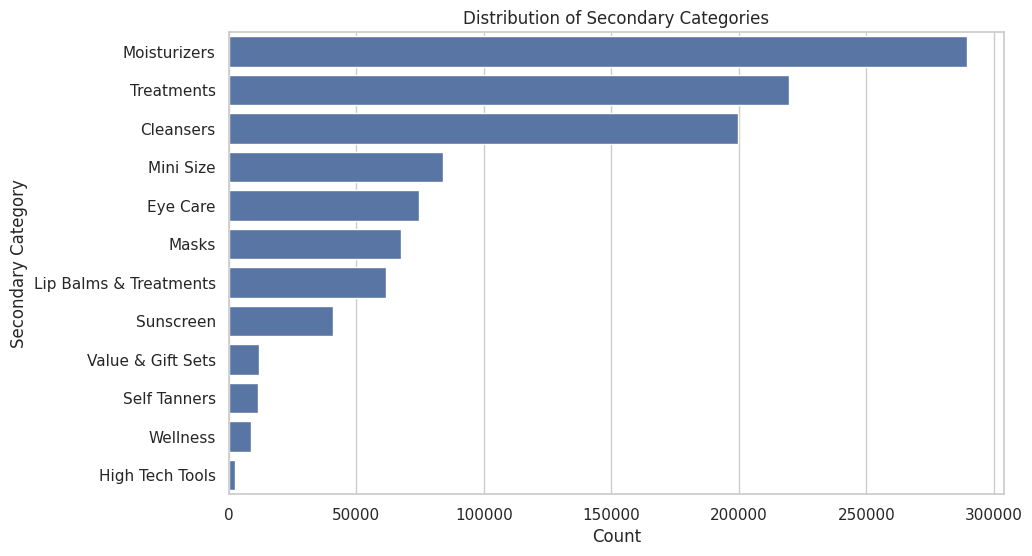

In [87]:
# Visualize the distribution of secondary_category
plt.figure(figsize=(10, 6))
sns.countplot(y='secondary_category', data=df, order=df['secondary_category'].value_counts().index)
plt.title("Distribution of Secondary Categories")
plt.xlabel("Count")
plt.ylabel("Secondary Category")
plt.show()


#### Categorical variables 

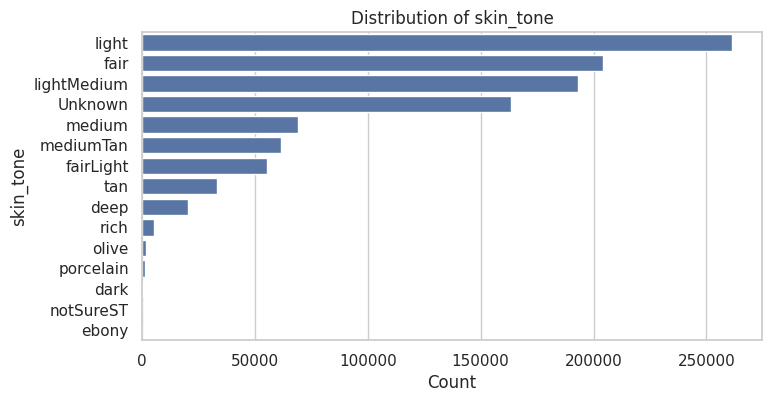

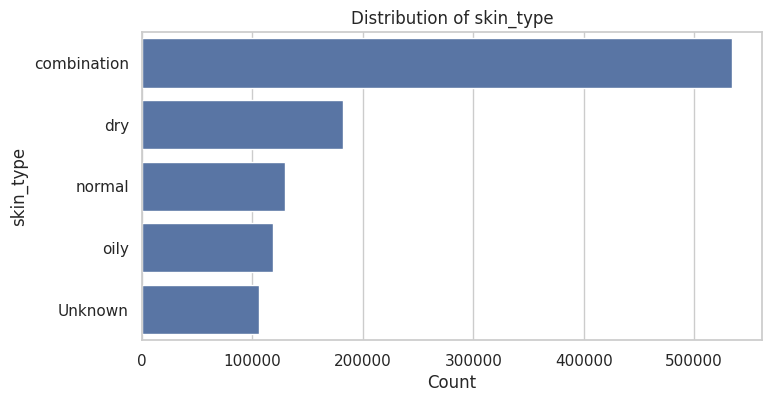

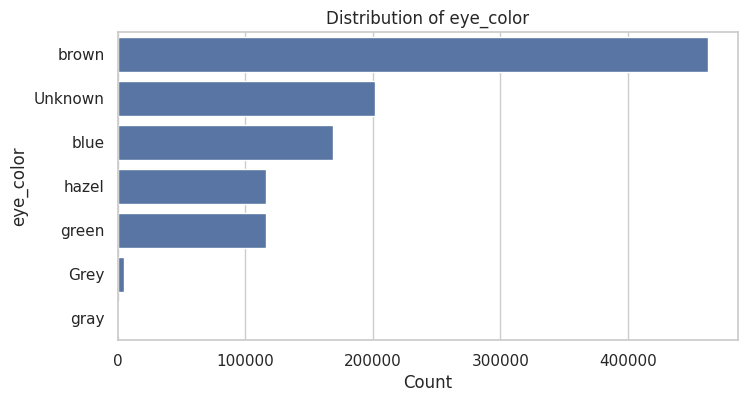

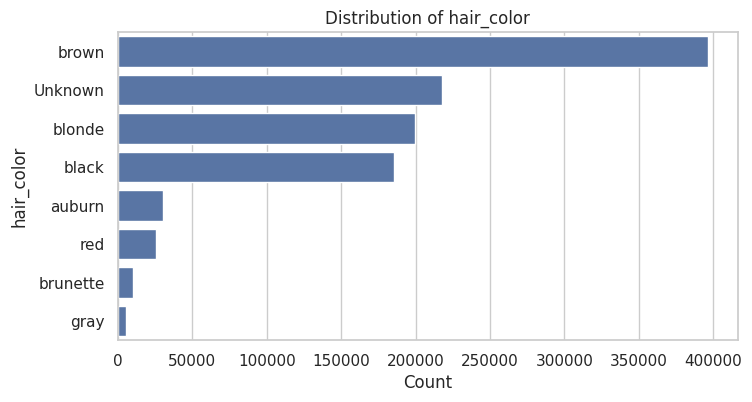

In [88]:
# Count plots for user-related categorical features
categorical_columns = ['skin_tone', 'skin_type', 'eye_color', 'hair_color']
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


/tmp/ipykernel_11793/1775896727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")


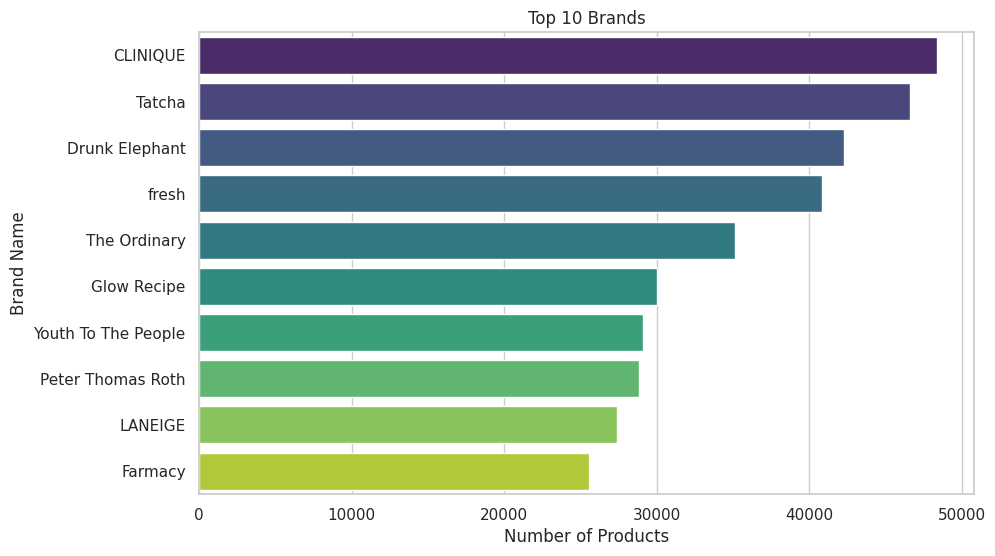

In [89]:
# Top 10 brands by count
top_brands = df['brand_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 10 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand Name")
plt.show()


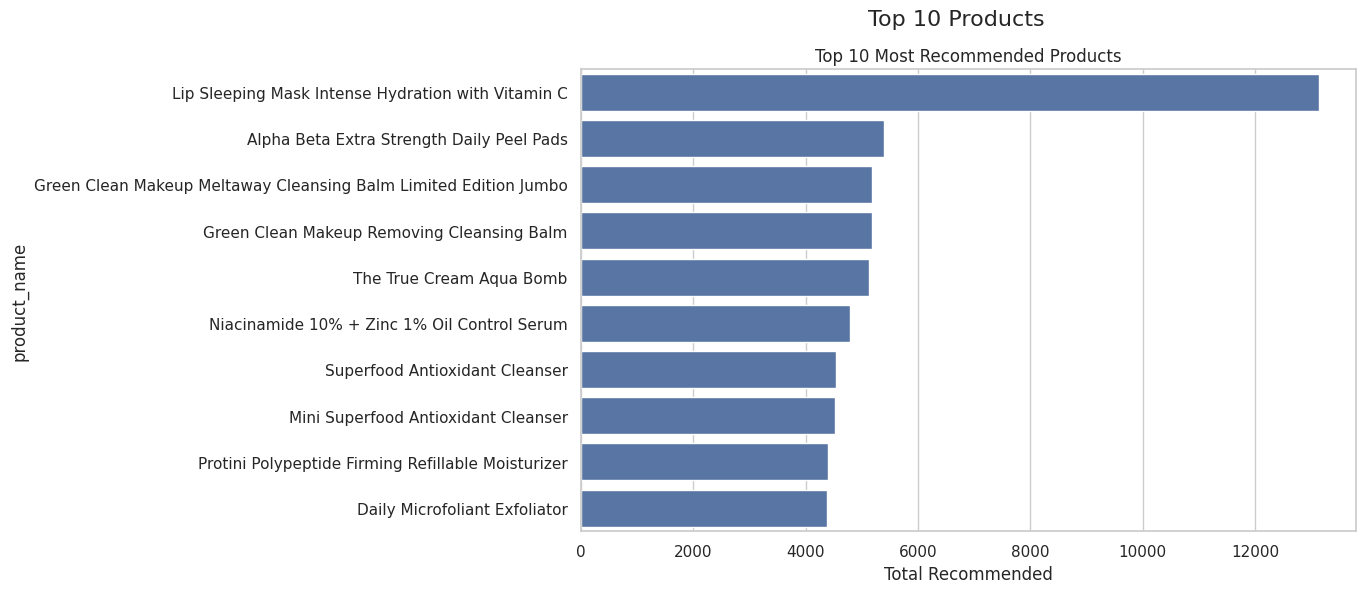

In [90]:
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(hspace=0.5)

# Top 10 Most Recommended Products:
# Group by product identifier fields and sum the 'is_recommended' column.
most_recommended = (df.groupby(['product_id', 'product_name', 'brand_name'])
                      .sum(numeric_only=True)['is_recommended']
                      .reset_index()
                      .sort_values('is_recommended', ascending=False)
                      .head(10))

# Create a bar plot for the top recommended products
sns.barplot(data=most_recommended, x='is_recommended', y='product_name', ax=ax1)
ax1.set_title("Top 10 Most Recommended Products")
ax1.set_xlabel("Total Recommended")

plt.suptitle("Top 10 Products", fontsize=16)
plt.show()

#### Numeric Columns

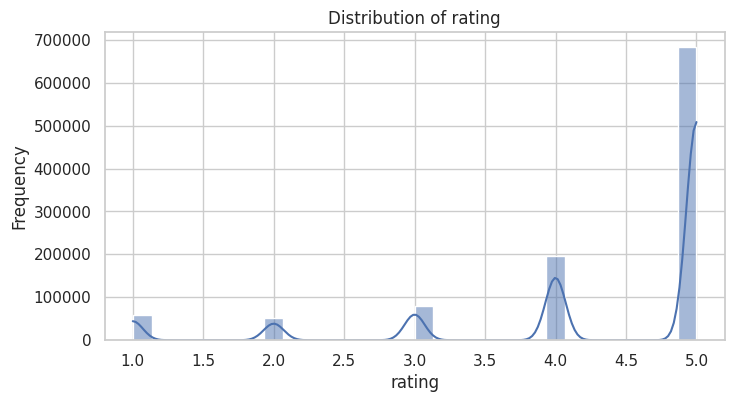

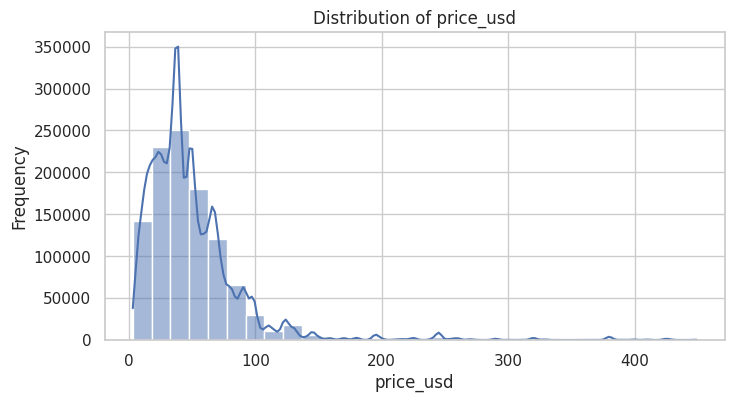

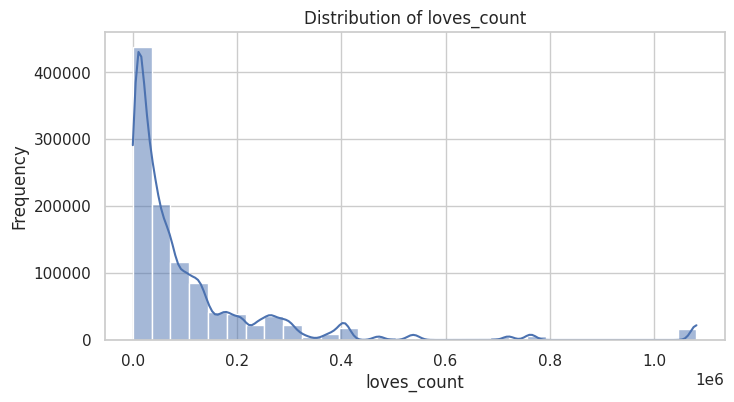

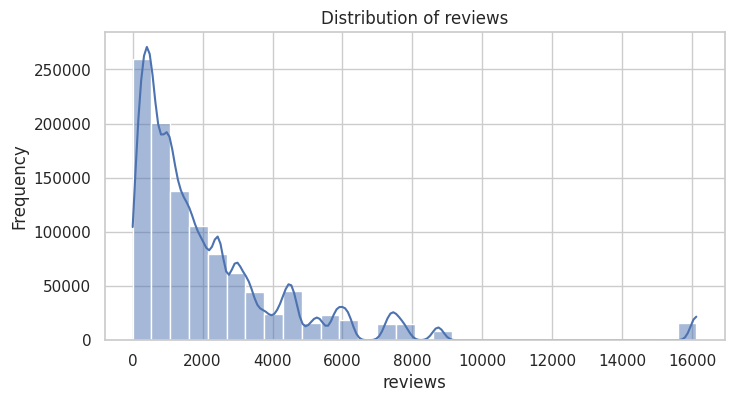

In [91]:
# Set style for better visuals
sns.set(style="whitegrid")

# Histograms for numeric columns
numeric_columns = ['rating', 'price_usd', 'loves_count', 'reviews']
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


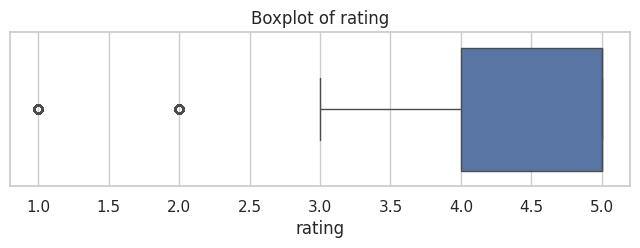

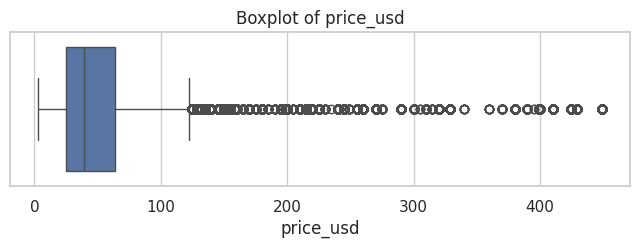

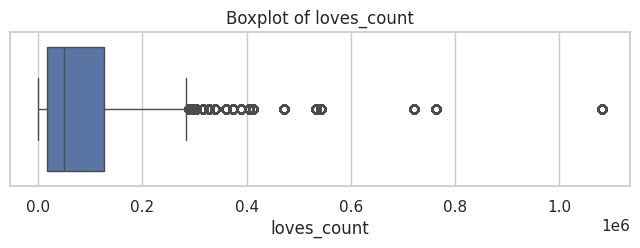

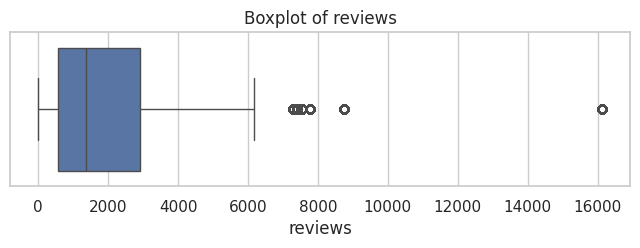

In [92]:
# List of numeric columns to analyze
numeric_columns = ['rating', 'price_usd', 'loves_count', 'reviews']

# Additionally, create boxplots to inspect potential outliers
for col in numeric_columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#### Correlation and Relationship Analysis

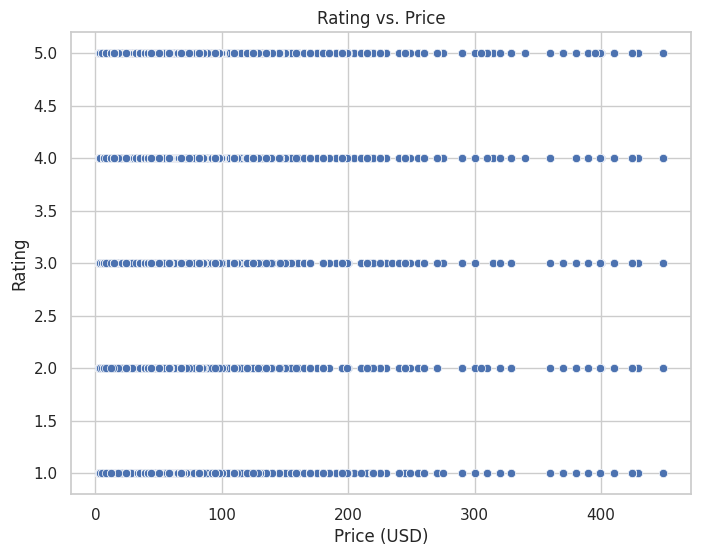

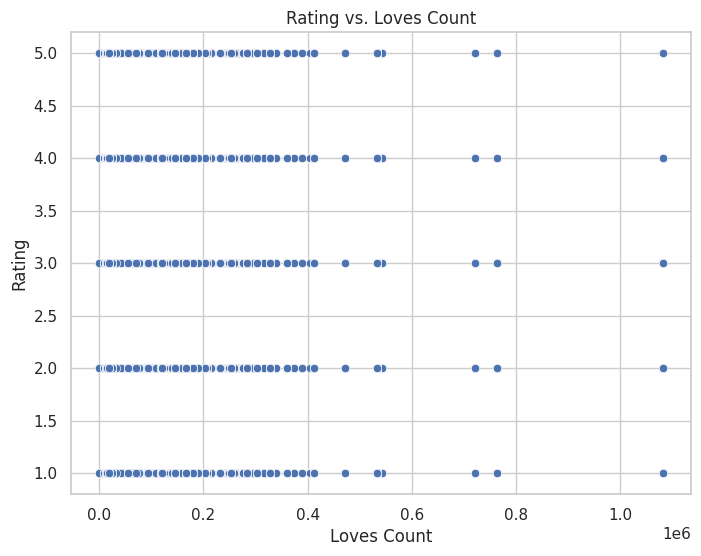

In [93]:
# Scatter plot for rating vs. price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='price_usd', y='rating', data=df)
plt.title("Rating vs. Price")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.show()

# Scatter plot for rating vs. loves_count
plt.figure(figsize=(8, 6))
sns.scatterplot(x='loves_count', y='rating', data=df)
plt.title("Rating vs. Loves Count")
plt.xlabel("Loves Count")
plt.ylabel("Rating")
plt.show()


/tmp/ipykernel_11793/516035031.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cheapest, x='price_usd', y='product_name', ax=ax2, palette='mako')


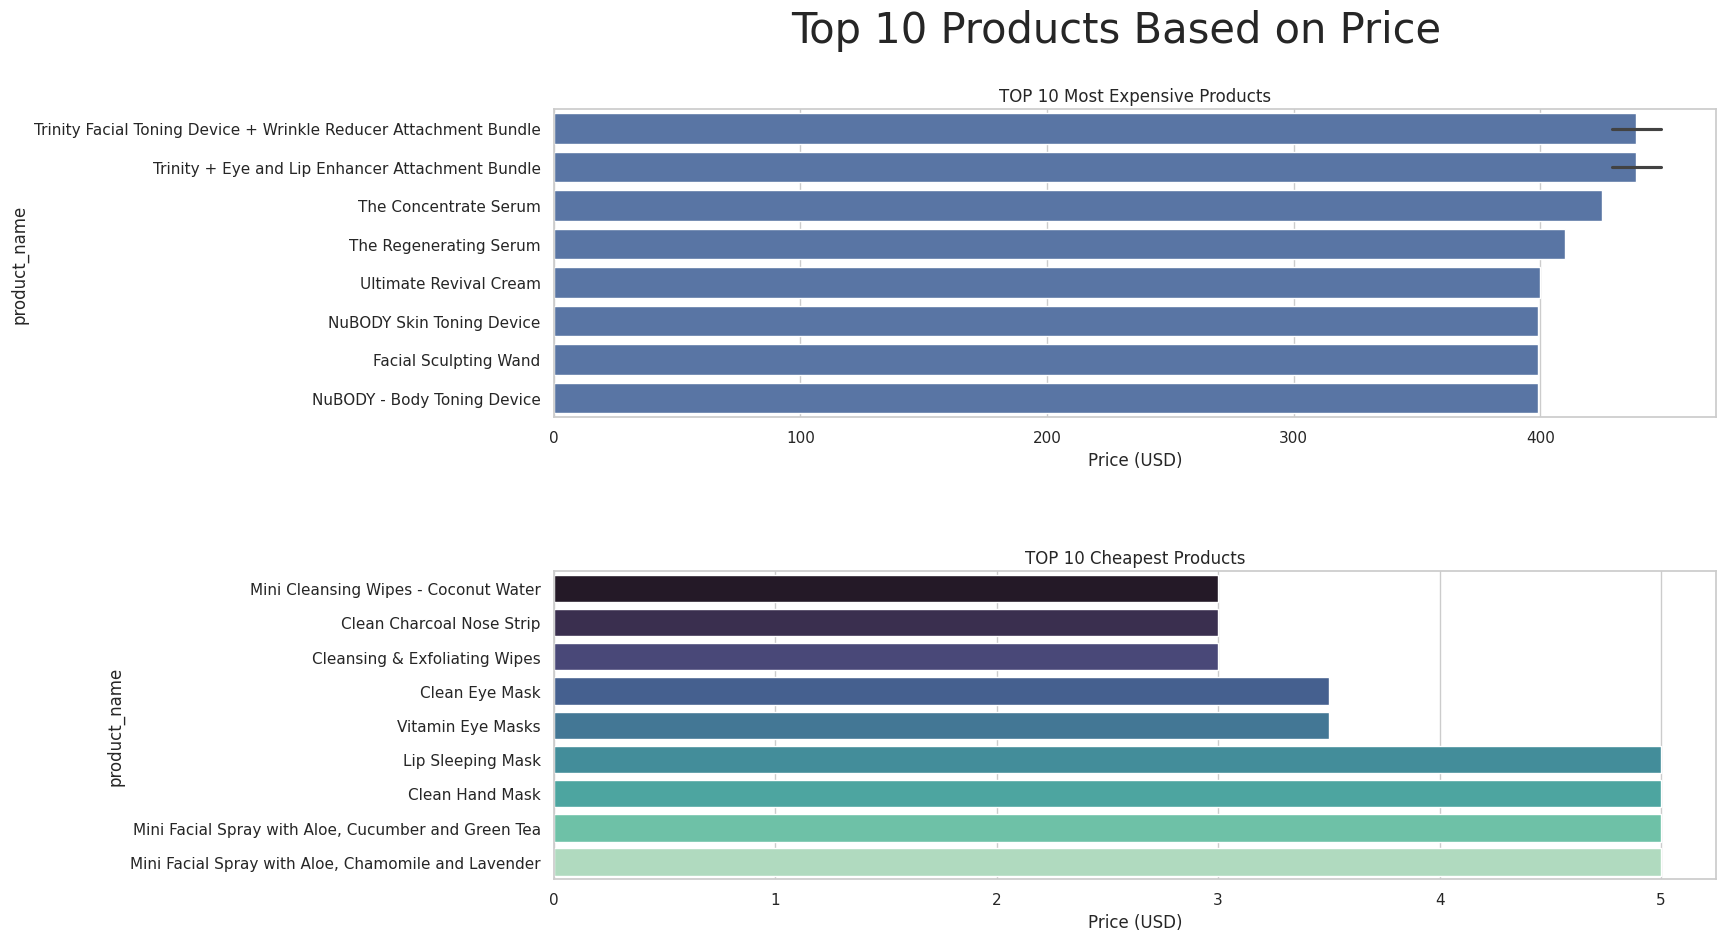

In [94]:
# Create a DataFrame with unique product information
product_prices = df[['product_id', 'product_name', 'price_usd']].drop_duplicates()

# Top 10 most expensive products (sorted descending by price)
most_expensive = product_prices.sort_values(by='price_usd', ascending=False).head(10)

# Top 10 cheapest products (sorted ascending by price)
cheapest = product_prices.sort_values(by='price_usd', ascending=True).head(10)

# Create subplots for the two bar plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
fig.subplots_adjust(hspace=0.5)

# Plot for Top 10 Most Expensive Products
sns.barplot(data=most_expensive, x='price_usd', y='product_name', ax=ax1)
ax1.set_title("TOP 10 Most Expensive Products")
ax1.set_xlabel("Price (USD)")

# Plot for Top 10 Cheapest Products
sns.barplot(data=cheapest, x='price_usd', y='product_name', ax=ax2, palette='mako')
ax2.set_title("TOP 10 Cheapest Products")
ax2.set_xlabel("Price (USD)")

plt.suptitle("Top 10 Products Based on Price", fontsize=30)
plt.show()

#### Text analysis

In [95]:
# Inspect sample reviews
print("Sample review_text:")
print(df['review_text'].dropna().head(10))

# Inspect sample ingredients
print("\nSample ingredients:")
print(df['ingredients'].dropna().head(10))


Sample review_text:
12    Nice consistency, however I’m not sure it’s do...
13    I cannot express how much I love this eye crea...
14    This depuffs super well. Does not help with da...
15    Love it! It keeps crows feet and fine lines aw...
16    I’m 46, and I can honestly say this has helped...
17    It was ok but no different frommy other cream ...
18    Cute packaging I’m really impressed with the r...
19    This is my favorited night time eye cream I ha...
20    I love this product. My fine lines around my e...
21    When applying onto under eyes make sure to not...
Name: review_text, dtype: object

Sample ingredients:
12    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
13    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
14    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
15    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
16    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
17    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
18    ['Water, Butylene Glycol

Clean the reviews text

In [96]:
# Download required NLTK data files (only need to do this once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Set up stop words and the lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_review(review):
    """
    Cleans a review string by lowercasing, tokenizing, removing punctuation,
    filtering out stop words, and lemmatizing tokens.
    
    Parameters:
    - review (str): The original review text.
    
    Returns:
    - List[str]: A list of cleaned tokens.
    """
    if isinstance(review, str):
        # Convert text to lowercase
        review = review.lower()
        # Tokenize text into words
        tokens = word_tokenize(review)
        # Remove punctuation and non-alphabetic tokens
        tokens = [word for word in tokens if word.isalpha()]
        # Remove stop words
        tokens = [word for word in tokens if word not in stop_words]
        # Lemmatize tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return tokens
    else:
        return []

# Example usage: Clean a sample review
sample_review = "This is hands down the best cleanser I’ve ever used!"
cleaned_tokens = clean_review(sample_review)
print(cleaned_tokens)

[nltk_data] Downloading package punkt to /home/alberto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alberto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/alberto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/alberto/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['hand', 'best', 'cleanser', 'ever', 'used']


In [ ]:
# Create a new column 'review_tokens' with the cleaned tokens
df['review_cleaned'] = df['review_text'].apply(clean_review)

# Display a few examples of the original review and its cleaned tokenized version
print(df[['review_text', 'review_cleaned']].head(10))

Generating word clouds for positive and negative reviews to visualize the most frequent words can help you understand the overall sentiment and themes in the data.

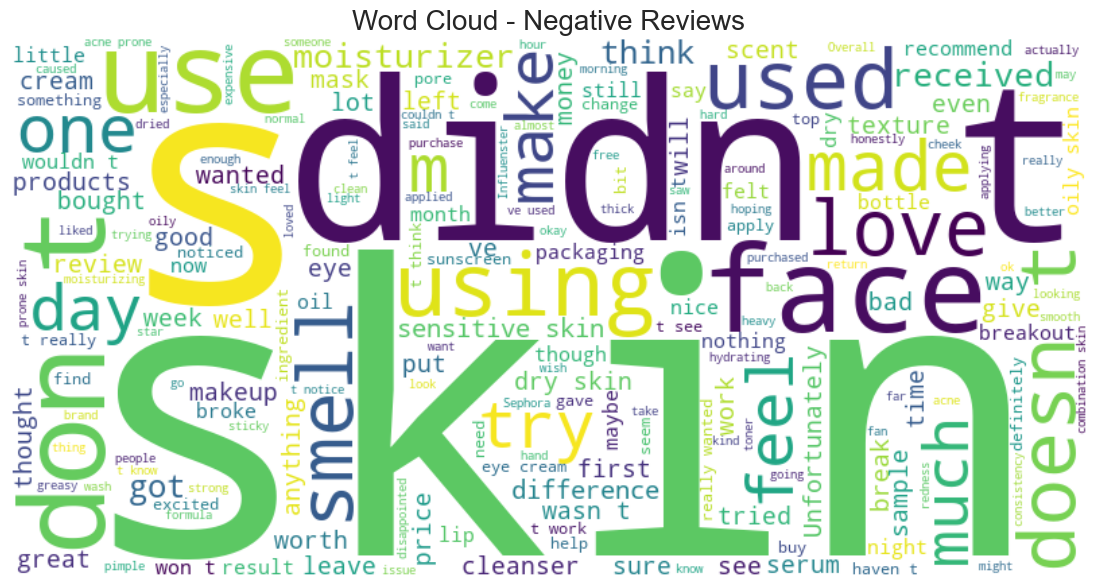

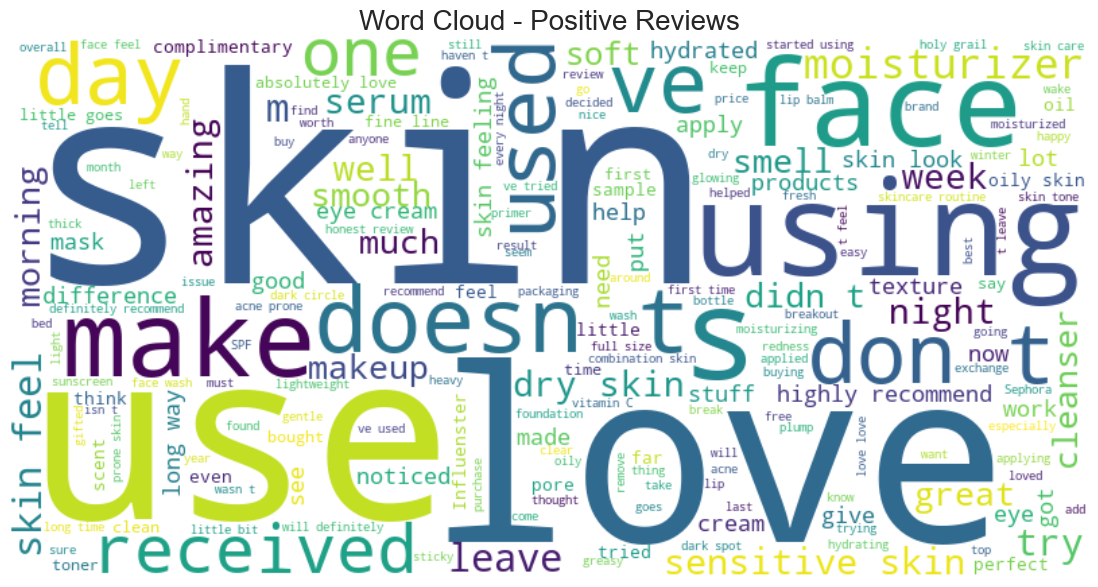

In [ ]:

# Split the dataset into negative and positive reviews based on a rating threshold (e.g., 4)
negative_df = df[df['rating'] <= 3]
positive_df = df[df['rating'] > 4]

# Concatenate all reviews into single strings
negative = " ".join(review for review in negative_df['review_text'].dropna())
positive = " ".join(review for review in positive_df['review_text'].dropna())

# Create a set of stop words and add any custom ones
stopwords = set(STOPWORDS)
stopwords.update(['read', 'more', 'product'])

def generate_wordcloud(data, title="Word Cloud"):
    wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400).generate(data)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

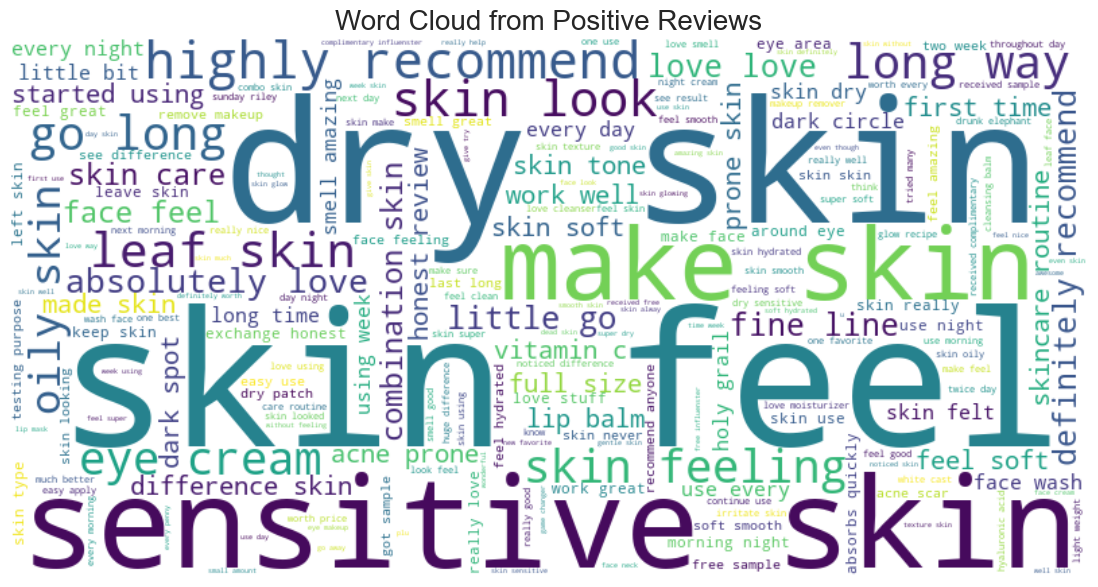

In [ ]:
# Convert token lists back to a string for the word cloud (for positive reviews)
positive_tokens_string = " ".join([" ".join(tokens) for tokens in df[df['rating'] > 4]['review_cleaned'].dropna()])
generate_wordcloud(positive_tokens_string, title="Word Cloud from Positive Reviews")


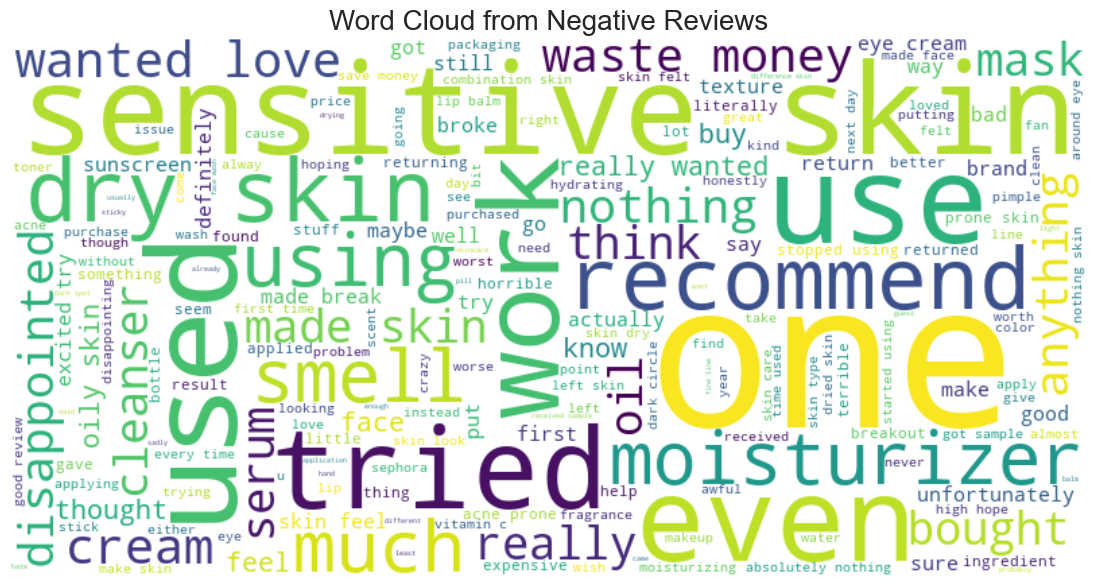

In [ ]:
# Convert token lists back to a string for the word cloud (for negative reviews)
negative_tokens_string = " ".join([" ".join(tokens) for tokens in df[df['rating'] < 2]['review_cleaned'].dropna()])
generate_wordcloud(negative_tokens_string, title="Word Cloud from Negative Reviews")


Prepare the ingredients for the vectorization

In [ ]:
import ast

def convert_list_to_string(val):
    """
    Convert a string representation of a list into a single string.
    
    Parameters:
        val (str): A string that represents a list, e.g., "['Water, Butylene Glycol, ...']".
        
    Returns:
        str: A single string with all the list items joined by a space.
    """
    try:
        # Safely evaluate the string to get an actual Python list
        items = ast.literal_eval(val)
        # If items is a list, join the elements; otherwise, return the original value.
        if isinstance(items, list):
            return " ".join(items)
        else:
            return val
    except Exception as e:
        # In case of any error (e.g., if it's not in list format), return the original value
        return val

# Apply this conversion to create a new column 'ingredients_cleaned'
df['ingredients_cleaned'] = df['ingredients'].apply(convert_list_to_string)

# Inspect the first few entries of the cleaned ingredients
print(df['ingredients_cleaned'].head(10))


12    Water, Butylene Glycol, Tricaprylyl Citrate, P...
13    Water, Butylene Glycol, Tricaprylyl Citrate, P...
14    Water, Butylene Glycol, Tricaprylyl Citrate, P...
15    Water, Butylene Glycol, Tricaprylyl Citrate, P...
16    Water, Butylene Glycol, Tricaprylyl Citrate, P...
17    Water, Butylene Glycol, Tricaprylyl Citrate, P...
18    Water, Butylene Glycol, Tricaprylyl Citrate, P...
19    Water, Butylene Glycol, Tricaprylyl Citrate, P...
20    Water, Butylene Glycol, Tricaprylyl Citrate, P...
21    Water, Butylene Glycol, Tricaprylyl Citrate, P...
Name: ingredients_cleaned, dtype: object


#### Save the dataset

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1070947 entries, 12 to 1100550
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   author_id            1070947 non-null  object 
 1   rating               1070947 non-null  float64
 2   is_recommended       910353 non-null   float64
 3   review_text          1070947 non-null  object 
 4   skin_tone            1070947 non-null  object 
 5   eye_color            1070947 non-null  object 
 6   skin_type            1070947 non-null  object 
 7   hair_color           1070947 non-null  object 
 8   product_id           1070947 non-null  object 
 9   product_name         1070947 non-null  object 
 10  brand_name           1070947 non-null  object 
 11  price_usd            1070947 non-null  float64
 12  ingredients          1070947 non-null  object 
 13  loves_count          1070947 non-null  int64  
 14  out_of_stock         1070947 non-null  int64  
 15  re


**Dataset Changes Summary**

The original dataset underwent extensive cleaning and feature engineering, resulting in a final consolidated DataFrame with 1,070,962 entries and 18 columns. Key changes include:

- **Data Merging and Deduplication:**  
  Multiple data sources (such as user reviews and product information) were merged to create a comprehensive dataset, ensuring that each product-review record is uniquely identified by the common key `product_id`.

- **Removal of Unnecessary Columns:**  
  Columns that were deemed redundant or not useful for further analysis were dropped. This streamlined the dataset and reduced noise.

- **Handling Missing Values:**  
  Rows with missing values in critical text fields (e.g., ingredients and review_text) were removed to ensure reliable input for text analysis. Missing values in certain categorical fields (like skin_tone, eye_color, skin_type, and hair_color) were addressed by imputation or appropriate handling, resulting in complete records in key columns.

- **Text Cleaning and Tokenization:**  
  The raw review text was cleaned—converted to lowercase, stripped of punctuation, and extra spaces removed—to create a new column (`review_cleaned`). This prepared the text data for subsequent vectorization and analysis.

- **Consolidation of Key Information:**  
  The final dataset now includes essential columns such as `author_id`, `rating`, `is_recommended`, `review_text`, `review_cleaned`, as well as product details (`product_id`, `product_name`, `brand_name`, `price_usd`, and `ingredients`) along with user attributes (`skin_tone`, `eye_color`, `skin_type`, `hair_color`). Additional columns like `loves_count`, `new`, `out_of_stock`, and `reviews` provide further insights into product popularity and user engagement.


In [ ]:
output_file = "cleaned_sephora_dataset.csv"
df.to_csv(output_file, index=False)
print(f"\nDataset successfully exported to {output_file}")


Dataset successfully exported to cleaned_sephora_dataset.csv


### Test the recommendation  functions

In [ ]:
def recommend_products_by_user_features(skintone, skintype, eyecolor, haircolor, secondary_category="All", percentile=0.85):
    """
    Recommend top products for a user based on their features and a selected product type.
    
    Parameters:
        skintone (str): The user's skin tone.
        skintype (str): The user's skin type.
        eyecolor (str): The user's eye color.
        haircolor (str): The user's hair color.
        secondary_category (str): The desired product type (e.g., 'moisturizers', 'cleansers'). 
                                  Use "All" to include all product types.
        percentile (float): (Optional) A percentile threshold (currently not used in the function).
        
    Returns:
        DataFrame: A DataFrame with the top 10 unique recommended products.
    """
    # Filter the DataFrame based on the user's features (using case-insensitive comparison)
    ddf = df[
        (df['skin_tone'].str.lower() == skintone.lower()) &
        (df['skin_type'].str.lower() == skintype.lower()) &
        (df['eye_color'].str.lower() == eyecolor.lower()) &
        (df['hair_color'].str.lower() == haircolor.lower())
    ]
    
    # If a specific secondary category is specified (other than "All"), filter accordingly.
    if secondary_category.lower() != "all":
        # First try an exact match
        exact_match = ddf[ddf['secondary_category'].str.lower() == secondary_category.lower()]
        if not exact_match.empty:
            ddf = exact_match
        else:
            # If no exact match, use partial matching
            ddf = ddf[ddf['secondary_category'].str.contains(secondary_category.lower(), na=False)]
    
    # Ensure that the rating is not null and select key columns including product_id
    recommendations = ddf[ddf['rating'].notnull()][['product_id', 'rating', 'product_name', 'brand_name', 'price_usd', 'secondary_category']]
    
    # Sort the filtered data by rating in descending order
    recommendations = recommendations.sort_values('rating', ascending=False)
    
    # Drop duplicate products based on 'product_id'
    recommendations = recommendations.drop_duplicates(subset=['product_id'])
    
    # Select the top 10 unique products
    recommendations = recommendations.head(10)
    
    print("Based on your features and selected product type, these are the top products for you:")
    return recommendations

# Example usage:
top_products = recommend_products_by_user_features('Fair', 'Dry', 'Blue', 'Blonde', secondary_category="moisturizers")
print(top_products)


Based on your features and selected product type, these are the top products for you:
       product_id  rating                                       product_name  \
1812       P12045     5.0                 Grape Water Moisturizing Face Mist   
595737    P446938     5.0  Lala Retro Whipped Refillable Moisturizer with...   
593324    P446930     5.0                     Cream Skin Toner & Moisturizer   
597641    P447200     5.0                              Baba Bomb Moisturizer   
601424    P447596     5.0       100% Organic Cold-Pressed Moroccan Argan Oil   
609926    P448185     5.0             Cicapair Tiger Grass Calming Gel Cream   
609253    P448184     5.0                  Cicapair Tiger Grass Calming Mist   
605061    P447781     5.0                                         Face Cream   
610941    P448202     5.0        Benefiance Wrinkle Smoothing Cream Enriched   
551248    P442840     5.0           Barrier+ Triple Lipid-Peptide Face Cream   

               brand_name  price_

Add sorting by price

In [ ]:
def recommend_products_by_user_features(skintone, skintype, eyecolor, haircolor, secondary_category="All", price_order=None, percentile=0.85):
    """
    Recommend top products for a user based on their features, selected product type,
    and optionally sort the recommendations by price.
    
    Parameters:
        skintone (str): The user's skin tone.
        skintype (str): The user's skin type.
        eyecolor (str): The user's eye color.
        haircolor (str): The user's hair color.
        secondary_category (str): The desired product type (e.g., 'moisturizers', 'cleansers').
                                  Use "All" to include all product types.
        price_order (str): If provided, must be either "asc" or "desc" to sort by price in ascending or descending order.
                           If None, sorting defaults to rating in descending order.
        percentile (float): (Optional) A percentile threshold (currently not used in the function).
        
    Returns:
        DataFrame: A DataFrame with the top 10 unique recommended products.
    """
    # Filter the DataFrame based on the user's features (case-insensitive)
    ddf = df[
        (df['skin_tone'].str.lower() == skintone.lower()) &
        (df['skin_type'].str.lower() == skintype.lower()) &
        (df['eye_color'].str.lower() == eyecolor.lower()) &
        (df['hair_color'].str.lower() == haircolor.lower())
    ]
    
    # Filter by secondary category if specified (exact match, then fallback to partial match)
    if secondary_category.lower() != "all":
        exact_match = ddf[ddf['secondary_category'].str.lower() == secondary_category.lower()]
        if not exact_match.empty:
            ddf = exact_match
        else:
            ddf = ddf[ddf['secondary_category'].str.contains(secondary_category.lower(), na=False)]
    
    # Ensure that the rating is not null and select key columns (including product_id)
    recommendations = ddf[ddf['rating'].notnull()][['product_id', 'rating', 'product_name', 'brand_name', 'price_usd', 'secondary_category']]
    
    # Sort by rating as default
    recommendations = recommendations.sort_values('rating', ascending=False)
    
    # Drop duplicate products based on product_id so each product appears only once
    recommendations = recommendations.drop_duplicates(subset=['product_id'])
    
    # If a price sorting order is specified, sort by price instead
    if price_order is not None:
        if price_order.lower() == "asc":
            recommendations = recommendations.sort_values('price_usd', ascending=True)
        elif price_order.lower() == "desc":
            recommendations = recommendations.sort_values('price_usd', ascending=False)
        else:
            print("Invalid price_order value. Use 'asc' for ascending or 'desc' for descending. Using default sorting by rating.")
    
    # Select the top 10 products from the sorted recommendations
    recommendations = recommendations.head(10)
    
    print("Based on your features and selected product type, these are the top products for you:")
    return recommendations

# Example usage:
top_products = recommend_products_by_user_features('Fair', 'Dry', 'Blue', 'Blonde', secondary_category="moisturizers", price_order="asc")
print(top_products)


Based on your features and selected product type, these are the top products for you:
       product_id  rating                                    product_name  \
512260    P440483     5.0  Facial Spray with Aloe, Cucumber and Green Tea   
511926    P440482     2.0     Facial Spray with Aloe, Herbs and Rosewater   
512400    P440484     4.0  Facial Spray with Aloe, Chamomile and Lavender   
601424    P447596     5.0    100% Organic Cold-Pressed Moroccan Argan Oil   
680576    P455365     5.0                 Vitamin B, C, and E Moisturizer   
406203    P427415     5.0     100% Organic Cold-Pressed Rose Hip Seed Oil   
942652    P479354     5.0                   Omega Water Cream Moisturizer   
544949    P442757     5.0                                         "B" Oil   
573311    P443834     5.0                    Rosehip Nourishing Night Oil   
1812       P12045     5.0              Grape Water Moisturizing Face Mist   

            brand_name  price_usd secondary_category  
512260   Ma

### Vectorization of ingridients

First remove duplicates

In [ ]:
df_unique = df.drop_duplicates(subset=['product_id']).reset_index(drop=True)
print("Deduplicated DataFrame info:")
print(df_unique.info())

Deduplicated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223 entries, 0 to 2222
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   author_id            2223 non-null   object 
 1   rating               2223 non-null   float64
 2   is_recommended       2223 non-null   float64
 3   review_text          2223 non-null   object 
 4   skin_tone            2223 non-null   object 
 5   eye_color            2223 non-null   object 
 6   skin_type            2223 non-null   object 
 7   hair_color           2223 non-null   object 
 8   product_id           2223 non-null   object 
 9   product_name         2223 non-null   object 
 10  brand_name           2223 non-null   object 
 11  price_usd            2223 non-null   float64
 12  ingredients          2223 non-null   object 
 13  loves_count          2223 non-null   int64  
 14  out_of_stock         2223 non-null   int64  
 15  reviews  

In [ ]:
# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer()

tfidf_matrix_unique = vectorizer.fit_transform(df_unique['ingredients_cleaned'])
print("TF-IDF matrix shape (unique):", tfidf_matrix_unique.shape)
print("Number of unique terms:", len(vectorizer.get_feature_names_out()))

TF-IDF matrix shape (unique): (2223, 4831)
Number of unique terms: 4831


In [ ]:
# Build a NearestNeighbors model on the deduplicated TF-IDF matrix using cosine similarity.
nn_model = NearestNeighbors(n_neighbors=50, metric='cosine', algorithm='brute')
nn_model.fit(tfidf_matrix_unique)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=50)

In [ ]:
# Query for similar products to the product at index 0 in the deduplicated DataFrame
query_vector = tfidf_matrix_unique[0]
distances, indices = nn_model.kneighbors(query_vector)

# Flatten the indices array (it has shape (1, n_neighbors))
neighbors = indices.flatten()

# Print query product info for reference
query_product_info = df_unique.iloc[0][['product_id', 'product_name', 'brand_name', 'price_usd']]
print("Product 0 info:")
print(query_product_info)
print("\n")


# Get the product_id of the query product
query_product_id = df_unique.iloc[0]['product_id']

# Filter out any neighbors that have the same product_id as the query product
filtered_neighbors = [i for i in neighbors if df_unique.iloc[i]['product_id'] != query_product_id]

# Retrieve product details for these neighbor indices
similar_products = df_unique.iloc[filtered_neighbors][['product_id', 'product_name', 'brand_name', 'price_usd']]

# Select the top 10 unique similar products
top_10_unique = similar_products.head(10)

print("Top 10 unique similar products to product at index 0:")
print(top_10_unique)

Product 0 info:
product_id                 P107306
product_name    Renewing Eye Cream
brand_name                   Murad
price_usd                     89.0
Name: 0, dtype: object


Top 10 unique similar products to product at index 0:
     product_id                                      product_name  \
911     P453929                 Retinol Youth Renewal Night Cream   
123      P38217                          Renewing Cleansing Cream   
229       P4039  Perfecting Day Cream Broad Spectrum SPF 30 PA+++   
1631    P479696                                Brighten Trial Kit   
1678    P480461                   Retinol Youth Renewal Eye Masks   
655     P440650                  Mini Retinol Youth Renewal Serum   
283     P411365                       Retinol Youth Renewal Serum   
407     P423145                          Age Reversal Eye Complex   
355     P419223                   Shaba Complex Firming Eye Serum   
489     P429515                       C-Tango Vitamin C Eye Cream   

     

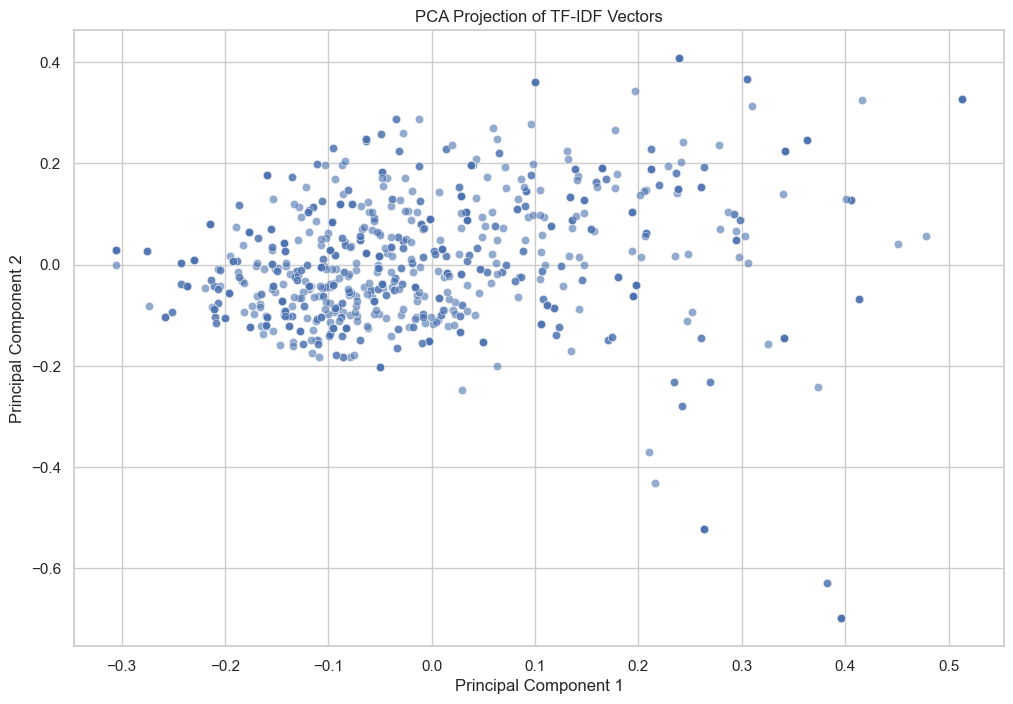

In [ ]:
# For reproducibility, set a random seed
np.random.seed(42)

# Sample a subset of 1000 products (adjust the number as needed)
sample_size = 1000
total_products = tfidf_matrix.shape[0]
sample_indices = np.random.choice(total_products, size=sample_size, replace=False)
tfidf_sample = tfidf_matrix[sample_indices]

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2, random_state=42)
# Convert the sparse matrix to dense array; for very large datasets, consider using sparse PCA or t-SNE
reduced_data = pca.fit_transform(tfidf_sample.toarray())

# Create a scatter plot of the 2D PCA results
plt.figure(figsize=(12, 8))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], alpha=0.6)
plt.title("PCA Projection of TF-IDF Vectors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### Content-Based Module

A module that focuses on ingredient similarity or textual content analysis to find similar products.

This recommendation system suggests skincare products based on user characteristics (e.g., skin tone, skin type, eye color, hair color) and product ingredient similarity. It combines user feature filtering with content-based filtering using TF-IDF and cosine similarity.

In [ ]:
def recommend_products_by_user_features(skintone, skintype, eyecolor, haircolor, 
                                        secondary_category="All", price_order=None, percentile=0.85, 
                                        query_product_id=None):
    """
    Recommend top products for a user based on their features and ingredient similarity.
    
    Parameters:
        skintone (str): The user's skin tone.
        skintype (str): The user's skin type.
        eyecolor (str): The user's eye color.
        haircolor (str): The user's hair color.
        secondary_category (str): The desired product type (e.g., 'moisturizers', 'cleansers').
                                  Use "All" to include all product types.
        price_order (str): Sort by price ("asc" or "desc"). Defaults to sorting by rating.
        percentile (float): Threshold for filtering (currently unused).
        query_product_id (str): Optional product ID to find similar products based on ingredients.
        
    Returns:
        DataFrame: Top 10 recommended products.
    """

    # Step 1: Filter by user features
    ddf = df[
        (df['skin_tone'].str.lower() == skintone.lower()) & 
        (df['skin_type'].str.lower() == skintype.lower()) & 
        (df['eye_color'].str.lower() == eyecolor.lower()) & 
        (df['hair_color'].str.lower() == haircolor.lower())
    ]
    
    # Step 2: Filter by secondary category if specified
    if secondary_category.lower() != "all":
        exact_match = ddf[ddf['secondary_category'].str.lower() == secondary_category.lower()]
        if not exact_match.empty:
            ddf = exact_match
        else:
            ddf = ddf[ddf['secondary_category'].str.contains(secondary_category.lower(), na=False)]
    
    # Ensure rating is not null and select key columns
    recommendations = ddf[ddf['rating'].notnull()][['product_id', 'rating', 'product_name', 'brand_name', 'price_usd', 'secondary_category']]
    
    # Step 3: Drop duplicate products
    recommendations = recommendations.drop_duplicates(subset=['product_id'])

    # Step 4: Apply ingredient similarity if query_product_id is provided
    if query_product_id:
        if query_product_id not in df['product_id'].values:
            print(f"Product ID {query_product_id} not found in dataset.")
            return recommendations.head(10)

        # Find the index of the query product in the dataset
        query_index = df[df['product_id'] == query_product_id].index[0]

        # Compute cosine similarity between query product and all products
        query_vector = tfidf_matrix[query_index]
        cos_sim = cosine_similarity(query_vector, tfidf_matrix).flatten()

        # Sort and get top unique product recommendations (excluding query product itself)
        similar_indices = np.argsort(cos_sim)[::-1][1:51]  # Get top 50
        similar_products = df.iloc[similar_indices][['product_id', 'product_name', 'brand_name', 'price_usd', 'secondary_category']].drop_duplicates(subset=['product_id'])

        # Merge content-based results with filtered user-feature-based recommendations
        recommendations = pd.concat([recommendations, similar_products]).drop_duplicates(subset=['product_id'])

    # Step 5: Sort by price or rating
    if price_order:
        if price_order.lower() == "asc":
            recommendations = recommendations.sort_values('price_usd', ascending=True)
        elif price_order.lower() == "desc":
            recommendations = recommendations.sort_values('price_usd', ascending=False)
    else:
        recommendations = recommendations.sort_values('rating', ascending=False)

    # Step 6: Return top 10 recommendations
    recommendations = recommendations.head(10)
    
    print("Recommended products based on user features and ingredient similarity:")
    return recommendations

# Example Usage:
top_products = recommend_products_by_user_features('Fair', 'Dry', 'Blue', 'Blonde', 
                                                   secondary_category="moisturizers", 
                                                   price_order="asc", 
                                                   query_product_id="P107306")

print(top_products)


Recommended products based on user features and ingredient similarity:
       product_id  rating                                    product_name  \
511926    P440482     2.0     Facial Spray with Aloe, Herbs and Rosewater   
512224    P440483     5.0  Facial Spray with Aloe, Cucumber and Green Tea   
512400    P440484     4.0  Facial Spray with Aloe, Chamomile and Lavender   
601424    P447596     5.0    100% Organic Cold-Pressed Moroccan Argan Oil   
680576    P455365     5.0                 Vitamin B, C, and E Moisturizer   
404880    P427415     5.0     100% Organic Cold-Pressed Rose Hip Seed Oil   
942530    P479354     5.0                   Omega Water Cream Moisturizer   
544848    P442757     5.0                                         "B" Oil   
573256    P443834     3.0                    Rosehip Nourishing Night Oil   
1812       P12045     5.0              Grape Water Moisturizing Face Mist   

            brand_name  price_usd secondary_category  
511926   Mario Badescu    


1. **User Feature-Based Filtering**  
   - The system first filters products based on user-provided characteristics (e.g., "Fair" skin, "Dry" skin type).
   - It also allows filtering by product category (e.g., "moisturizers") to refine recommendations.

2. **Content-Based Filtering (Ingredient Similarity)**  
   - Each product's ingredient list is transformed into a **TF-IDF vector**, which represents the importance of each term.
   - Using **cosine similarity**, we measure how similar two products are based on their ingredients.
   - This helps find products that have a similar composition but might belong to different brands.

3. **Ranking & Sorting**  
   - The system removes duplicate products (to avoid recommending the same product multiple times).
   - The user can choose to sort recommendations by **price** (ascending/descending) or **rating**.

4. **Final Recommendations**  
   - The system selects the top 10 unique products that match both **user preferences** and **ingredient similarity**.


### Hybrid Recommendation System

Integrate the content-based recommendation (using ingredients similarity) with user-feature filtering. 

In [ ]:
def hybrid_recommendation(
    skintone, skintype, eyecolor, haircolor,
    secondary_category="All", price_order=None, 
    brand_filter="All", price_range=None,
    num_recommendations=10,
    ingredient_input=None, 
    vectorizer=vectorizer, 
    tfidf_matrix=tfidf_matrix
):
    """
    Hybrid recommendation system combining user-feature filtering with ingredient-based similarity.
    
    Returns a DataFrame of top recommended products.
    """
    # Ensure df has a reset index to match tfidf_matrix
    df.reset_index(drop=True, inplace=True)

    # Step 1: Filter products based on user features
    filtered_df = df[
        (df['skin_tone'].str.lower() == skintone.lower()) &
        (df['skin_type'].str.lower() == skintype.lower()) &
        (df['eye_color'].str.lower() == eyecolor.lower()) &
        (df['hair_color'].str.lower() == haircolor.lower())
    ]
    
    # Step 2: Apply category filtering
    if secondary_category.lower() != "all":
        filtered_df = filtered_df[filtered_df['secondary_category'].str.lower() == secondary_category.lower()]
    
    # Step 3: Apply brand filter
    if brand_filter.lower() != "all":
        filtered_df = filtered_df[filtered_df['brand_name'].str.lower() == brand_filter.lower()]
    
    # Step 4: Apply price filter
    if price_range:
        min_price, max_price = price_range
        filtered_df = filtered_df[(filtered_df['price_usd'] >= min_price) & (filtered_df['price_usd'] <= max_price)]
    
    # Step 5: Ingredient-based similarity (if input provided)
    if ingredient_input and not filtered_df.empty:
        input_vector = vectorizer.transform([ingredient_input])

        # Match filtered_df indices with df indices
        valid_indices = filtered_df.index.intersection(df.index)
        if valid_indices.empty:
            return pd.DataFrame()  # Return empty DataFrame if no matches found

        similarity_scores = cosine_similarity(input_vector, tfidf_matrix[valid_indices]).flatten()

        # Assign similarity scores to the filtered dataframe
        filtered_df = filtered_df.loc[valid_indices].copy()
        filtered_df['similarity_score'] = similarity_scores
        
        # Sort by similarity
        filtered_df = filtered_df.sort_values(by='similarity_score', ascending=False)
    
    # Step 6: Remove duplicates and sort
    filtered_df = filtered_df.drop_duplicates(subset=['product_id'])
    if price_order:
        if price_order.lower() == "asc":
            filtered_df = filtered_df.sort_values(by='price_usd', ascending=True)
        elif price_order.lower() == "desc":
            filtered_df = filtered_df.sort_values(by='price_usd', ascending=False)
    else:
        filtered_df = filtered_df.sort_values(by=['similarity_score', 'rating'], ascending=[False, False])

    # Select only relevant columns for output
    final_df = filtered_df[['product_name', 'brand_name', 'price_usd', 'rating', 'ingredients_cleaned']].head(num_recommendations)
    
    return final_df

# Example usage
recommendations = hybrid_recommendation(
    skintone='Fair', skintype='Dry', eyecolor='Blue', haircolor='Blonde', 
    secondary_category="moisturizers", price_order="asc", brand_filter="All", 
    price_range=(10, 100), ingredient_input="Hyaluronic Acid", num_recommendations=10
)
print(recommendations)


                                             product_name          brand_name  \
390889        100% Organic Cold-Pressed Rose Hip Seed Oil        The Ordinary   
917476                      Omega Water Cream Moisturizer      The INKEY List   
528603                                            "B" Oil        The Ordinary   
556250                       Rosehip Nourishing Night Oil      The INKEY List   
599276                      SOS Daily Rescue Facial Spray     Tower 28 Beauty   
1787                   Grape Water Moisturizing Face Mist            Caudalie   
884069                  Symbright Brightening Moisturizer      The INKEY List   
982805               Ultra Glow Toner with Vitamins C + E  SEPHORA COLLECTION   
871998  Mini TL Advanced  Tightening Neck Cream PLUS f...          StriVectin   
930462  Mini Lapis Blue Tansy Face Oil - For Oily & Ac...           Herbivore   

        price_usd  rating                                ingredients_cleaned  
390889      10.90     5.0    